## Modelado con Gaussian Mixture Model (GMM)


In [398]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import warnings
from math import pi
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


warnings.filterwarnings('ignore')


### Preparacion de datos

In [399]:
df_dqi =pd.read_csv('./Data/Processed/df_dqi_final.csv', delimiter=';')
df_dqi_pca = df_dqi.drop(columns=['folio_integrante','edad', 'ponderador', 'grupo','resultado_general_entrevista'])

print("Columnas de df_dqi_pca: ")
print(df_dqi_pca.columns)


Columnas de df_dqi_pca: 
Index(['macronutrients_dqi', 'fatty_acids_dqi', 'balance_dqi',
       'empty_calories_dqi', 'total_fat_dqi', 'saturated_fat_dqi',
       'cholesterol_dqi', 'sodium_dqi', 'moderation_dqi', 'dqi_food_groups',
       'dqi_protein_sources', 'variety_dqi', 'dqi_adequacy_fruits',
       'dqi_adequacy_vegetables', 'dqi_adequacy_grains', 'dqi_adequacy_fiber',
       'dqi_adequacy_protein', 'dqi_adequacy_calcium', 'dqi_adequacy_iron',
       'dqi_adequacy_vitamin_c', 'dqi_adecuacy', 'dqi_total', 'region_Centro',
       'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte',
       'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península',
       'sexo_Mujer', 'estrato_Rural  ( <2500 Hab )',
       'estrato_Urbano ( 2500-99,999 Hab)'],
      dtype='object')


In [400]:
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=15))   
])

df_dqi_pca = pipeline.fit_transform(df_dqi_pca)

# Ver resultados
pca_model = pipeline.named_steps['pca']
print(f"Cantidad de componentes seleccionadas: {pca_model.n_components_}")
print(f"Porcentaje de varianza explicada: {pca_model.explained_variance_ratio_.sum() * 100:.2f}%")

df_dqi_pca = pd.DataFrame(df_dqi_pca, columns=[f"PC{i+1}" for i in range(pca_model.n_components_)])
df_dqi_pca.head()

Cantidad de componentes seleccionadas: 15
Porcentaje de varianza explicada: 90.66%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,0.560050,0.458432,0.348514,0.627531,0.477133,0.358532,-0.005317,-0.080983,0.482715,-0.299696,0.145780,0.120180,0.111291,-0.014983,0.016565
1,0.933954,0.125753,0.255348,0.705600,0.575939,0.347749,0.231043,-0.160024,-0.061143,0.367161,-0.196650,0.363558,-0.042829,-0.018390,-0.050924
2,0.984813,0.176949,0.260545,0.725718,0.567069,0.293605,0.175819,-0.221343,0.046442,0.337095,-0.380172,0.201551,0.043505,0.007387,-0.041734
3,0.012718,-0.430470,0.148054,0.736026,0.776365,0.286743,0.130320,-0.351362,-0.478603,0.075125,0.214561,0.573191,-0.104200,0.047117,0.096568
4,1.320348,0.056527,0.203088,0.607941,0.618769,0.298727,0.014224,-0.271601,-0.034773,-0.104282,-0.210458,0.324665,-0.177543,-0.066637,0.032824


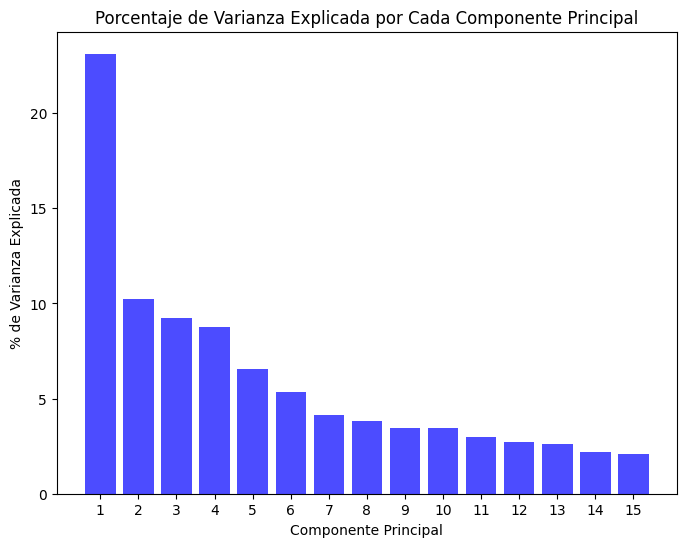

In [401]:
pca_model = pipeline.named_steps['pca']

# 1. Graficar el porcentaje de varianza explicada por cada componente
plt.figure(figsize=(8, 6))
plt.bar(np.arange(1, pca_model.n_components_ + 1), pca_model.explained_variance_ratio_ * 100, alpha=0.7, color='b')

# Etiquetas y título
plt.title('Porcentaje de Varianza Explicada por Cada Componente Principal')
plt.xlabel('Componente Principal')
plt.ylabel('% de Varianza Explicada')
plt.xticks(np.arange(1, pca_model.n_components_ + 1))  
plt.show()

### Funciones para evaluar GMM

In [402]:
def gmm(X, clusters):
    silhouette_scores = []

    for cluster in clusters:
        gmm = GaussianMixture(n_components=cluster, random_state=42, max_iter=10000)
        gmm.fit(X)
        labels = gmm.predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
        plot_silhouette(X, labels, cluster)

    return silhouette_scores

def plot_silhouette(X, labels, cluster):
    silhouette_vals = silhouette_samples(X, labels)
    y_lower, y_upper = 0, 0
    n_clusters = np.unique(labels).shape[0]
    plt.figure(figsize=(7, 5))

    for i in range(n_clusters):
        ith_cluster_silhouette_values = silhouette_vals[labels == i]
        ith_cluster_silhouette_values.sort()
        y_upper += len(ith_cluster_silhouette_values)
        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper

    plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
    plt.title(f'Grafica de silueta para el cluster {cluster}')
    plt.xlabel('Coeficiente de la silueta')
    plt.ylabel('Cluster')
    plt.tight_layout()
    plt.show()

def plot_silhouette_vs_cluster(clusters, silhouette_scores):
    plt.figure(figsize=(8, 6))
    plt.plot(clusters, silhouette_scores, marker='o', linestyle='-', color='b')
    plt.title('Coeficiente de la silueta por clusters')
    plt.xlabel('Clusters')
    plt.ylabel('Coeficiente de la silueta')
    plt.grid(True)
    plt.show()

def plot_centroid_radar(centroides, cluster):
    num_features = centroides.shape[1]
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1] 

    plt.figure(figsize=(8, 8))
    
    for i in range(centroides.shape[0]):
        values = centroides[i].tolist()
        values += values[:1]  
        plt.subplot(1, 1, 1)
        plt.fill(angles, values, alpha=0.25)
        plt.plot(angles, values, label=f'Cluster {i + 1}')

    plt.xticks(angles[:-1], [f'Feature {i + 1}' for i in range(num_features)])
    plt.title(f'Grafica para cluster {cluster}')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def plot_component_spider_plotly(means, n_components):
    num_features = means.shape[1]
    feature_labels = [f'C {i + 1}' for i in range(num_features)]
    data = []
    for i in range(n_components):
        values = means[i].tolist() + [means[i][0]] 
        data.append(values)

    df = pd.DataFrame(data, columns=feature_labels + ['Caracteristica 1'])
    df['componente'] = [f'componente {i + 1}' for i in range(n_components)]
    df = pd.melt(df, id_vars='componente', value_vars=feature_labels, 
                 var_name='Caracteristica', value_name='Valor')
    fig = px.line_polar(df, r='Valor', theta='Caracteristica', color='componente', 
                        line_close=True, title=f'Spider Plot para {n_components} componentes')
    fig.update_traces(fill='toself', opacity=0.25)
    fig.show()


### Ejecutamos la evaluacion de GMM con los datos listos

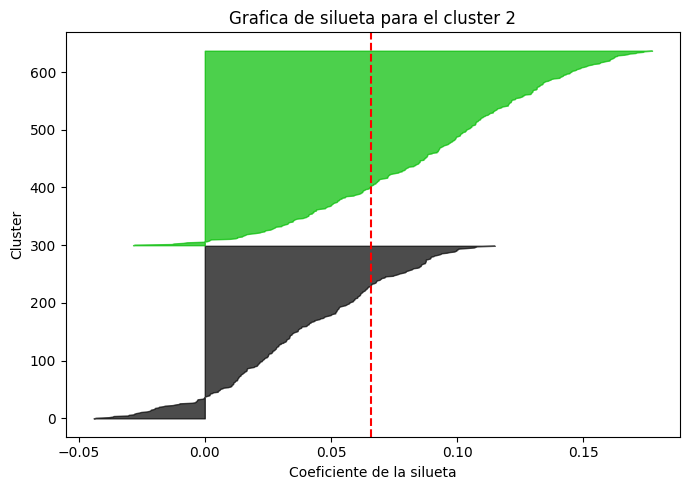

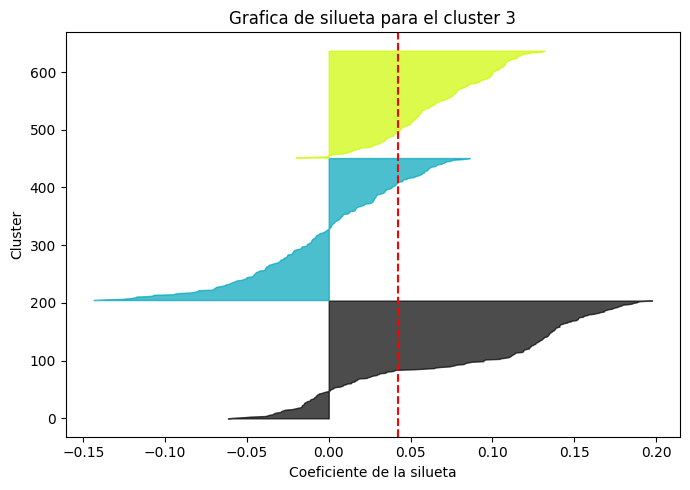

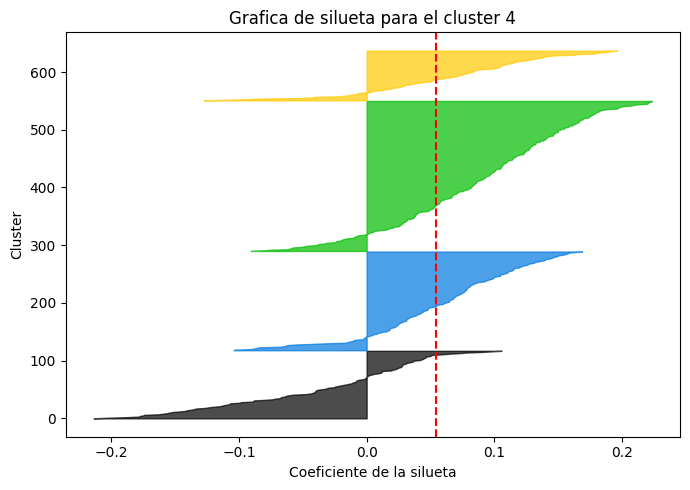

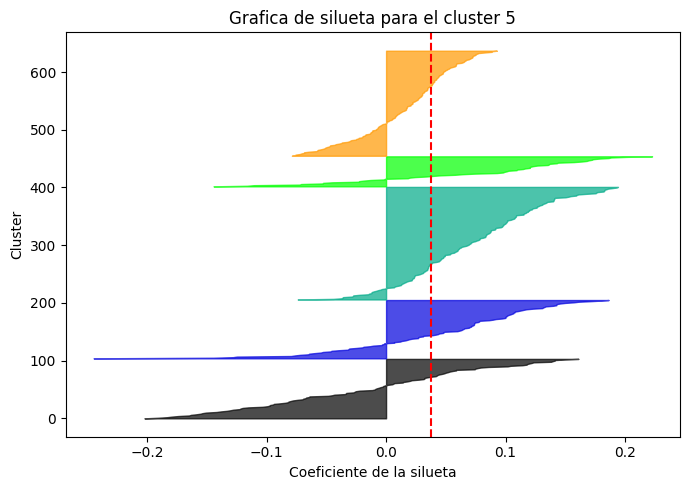

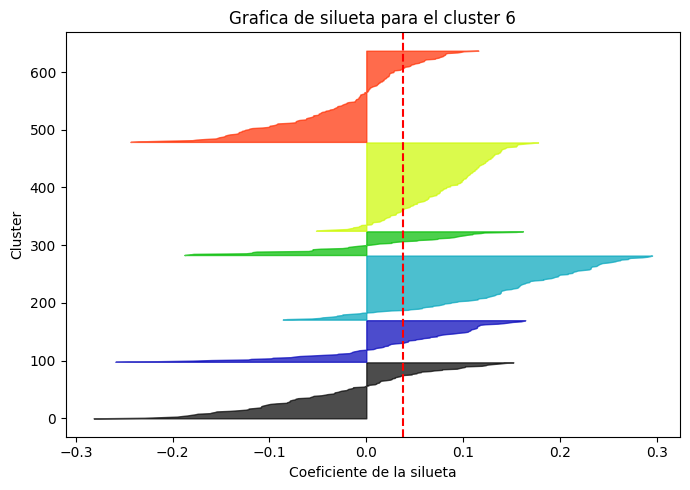

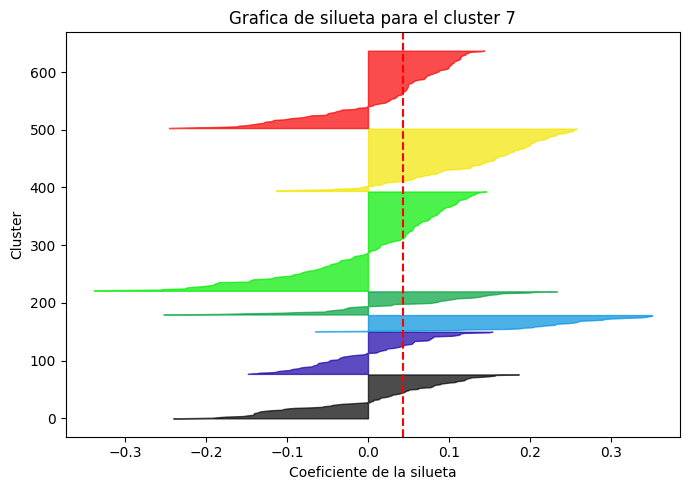

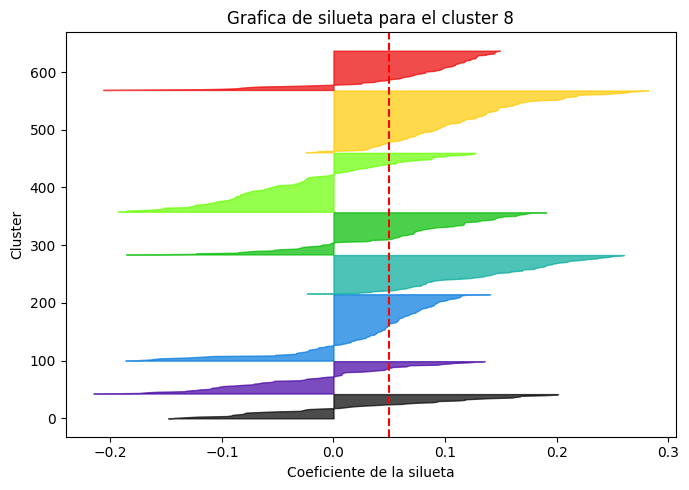

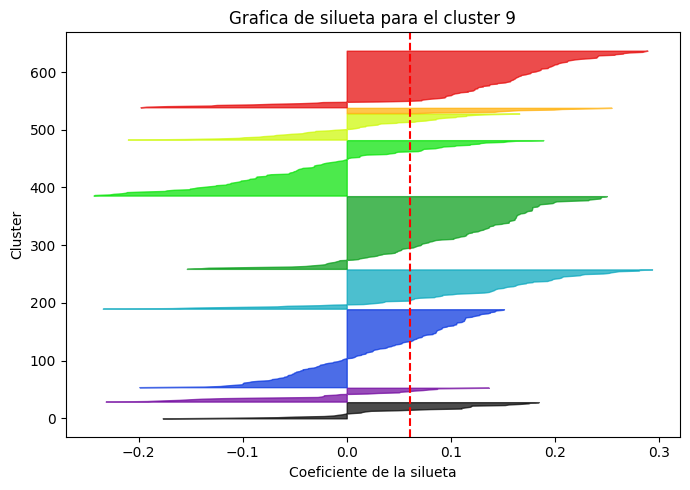

cluster = 2, Puntaje de Silueta = 0.06569793001838095
cluster = 3, Puntaje de Silueta = 0.042314742072223535
cluster = 4, Puntaje de Silueta = 0.05458553351953126
cluster = 5, Puntaje de Silueta = 0.037467794435954854
cluster = 6, Puntaje de Silueta = 0.03792105861827331
cluster = 7, Puntaje de Silueta = 0.04308318684695423
cluster = 8, Puntaje de Silueta = 0.04972539411267666
cluster = 9, Puntaje de Silueta = 0.06065891826364272


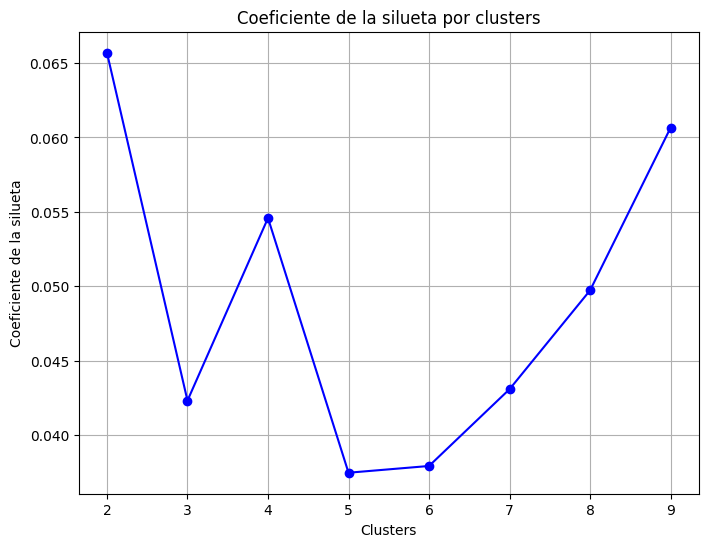

In [403]:
clusters = range(2, 10)  
puntaje_de_silueta = gmm(df_dqi_pca, clusters)
for cluster, score in zip(clusters, puntaje_de_silueta):
    print(f'cluster = {cluster}, Puntaje de Silueta = {score}')

plot_silhouette_vs_cluster(clusters, puntaje_de_silueta)


In [404]:
components = 2
gmm = GaussianMixture(n_components=components, random_state=42, max_iter=10000)
gmm.fit(df_dqi_pca)
labels = gmm.predict(df_dqi_pca)
plot_component_spider_plotly(gmm.means_,components)
score = silhouette_score(df_dqi_pca, labels)

print(score)


0.06569793001838095


In [405]:
df_dqi = df_dqi.assign(Cluster=labels)
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)",Cluster
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,True,False,False,False,False,False,True,False,False,0
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,True,False,False,False,False,False,True,False,False,0
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,True,False,False,False,False,False,True,False,False,0
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,True,False,False,False,False,False,True,False,False,0
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,...,True,False,False,False,False,False,True,False,False,0


In [406]:


df_dqi['region'] = df_dqi[['region_Centro', 'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península']].idxmax(axis=1)
df_dqi['estrato'] = df_dqi[['estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)']].idxmax(axis=1)
df_dqi.drop(columns=['region_Centro', 'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península', 'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'], inplace=True)
df_dqi['sexo'] = df_dqi['sexo_Mujer'].map({True: 'Mujer', False: 'Hombre'})
df_dqi.drop(columns=['sexo_Mujer'], inplace=True)
df_dqi['region'] = df_dqi['region'].apply(lambda x: x.split('_')[1])
df_dqi['estrato'] = df_dqi['estrato'].apply(lambda x: x.split('_')[1])
df_dqi['ponderador'] = df_dqi['ponderador'].div(df_dqi['ponderador'].sum())
df_dqi.head()



,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,dqi_adecuacy,dqi_total,edad,ponderador,grupo,resultado_general_entrevista,Cluster,region,estrato,sexo
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,31,60,51,0.000122,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,32,58,26,0.000723,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,31,60,62,0.000099,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,20,40,33,0.000385,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,...,37,63,60,0.000222,Adolescentes y Adultos,1,0,Centro Norte,Rural ( <2500 Hab ),Mujer


### Distribucion de las variables por cluster 

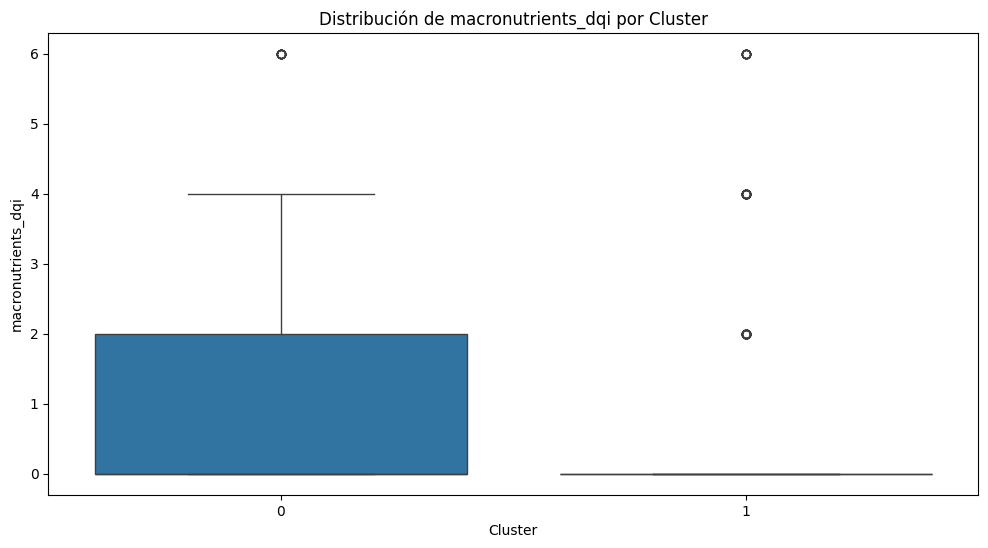

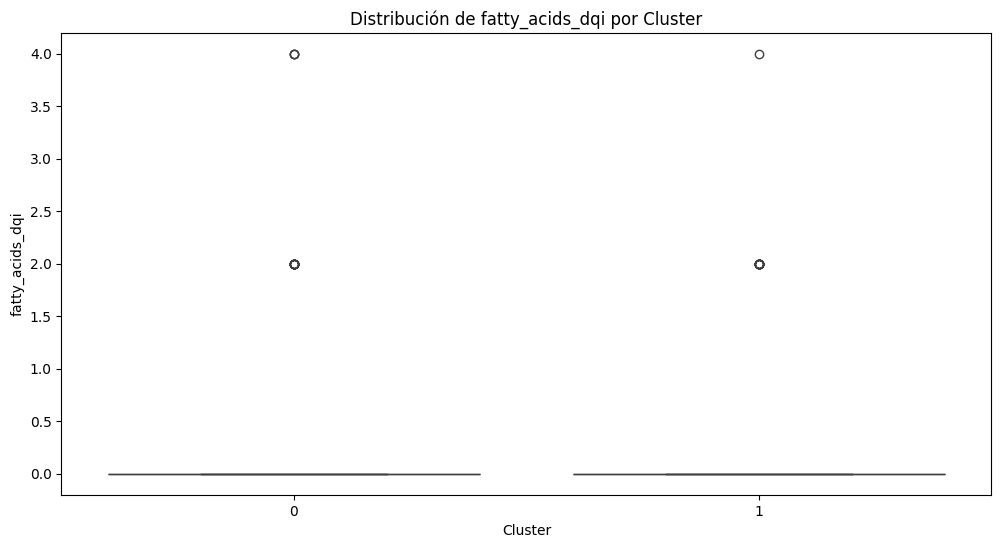

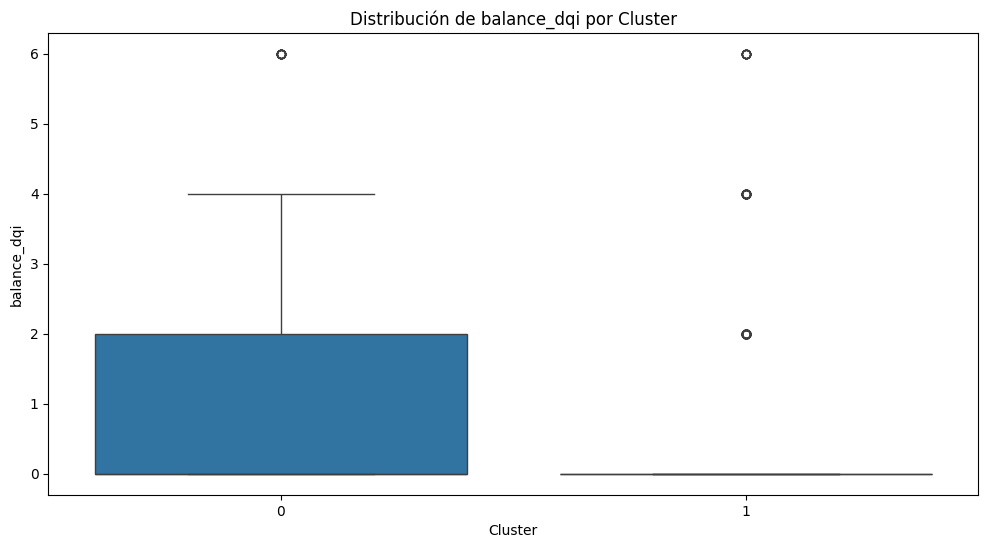

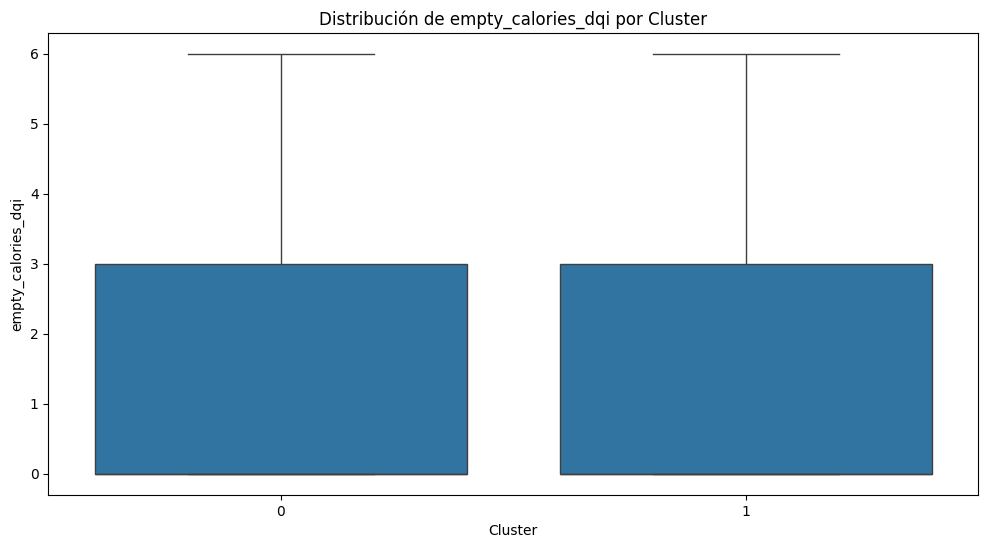

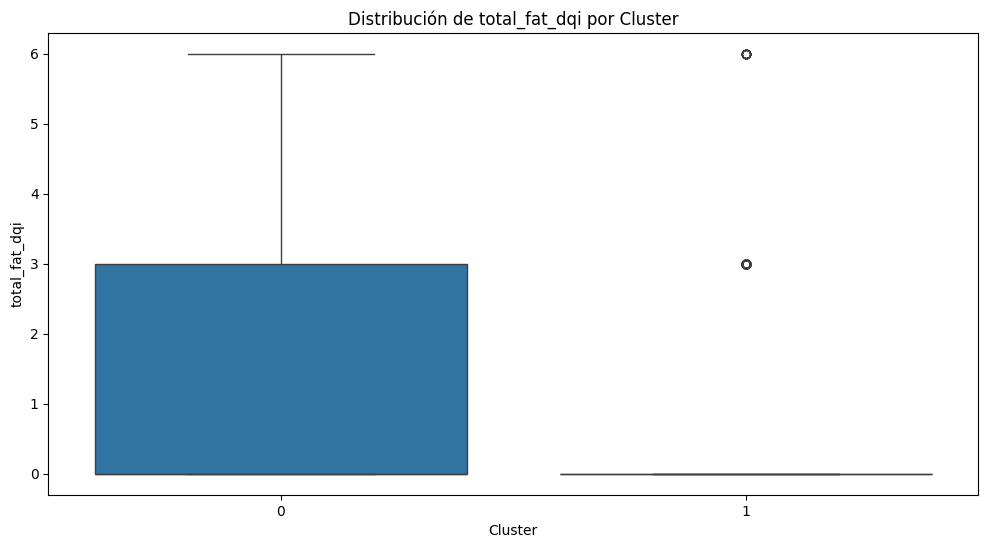

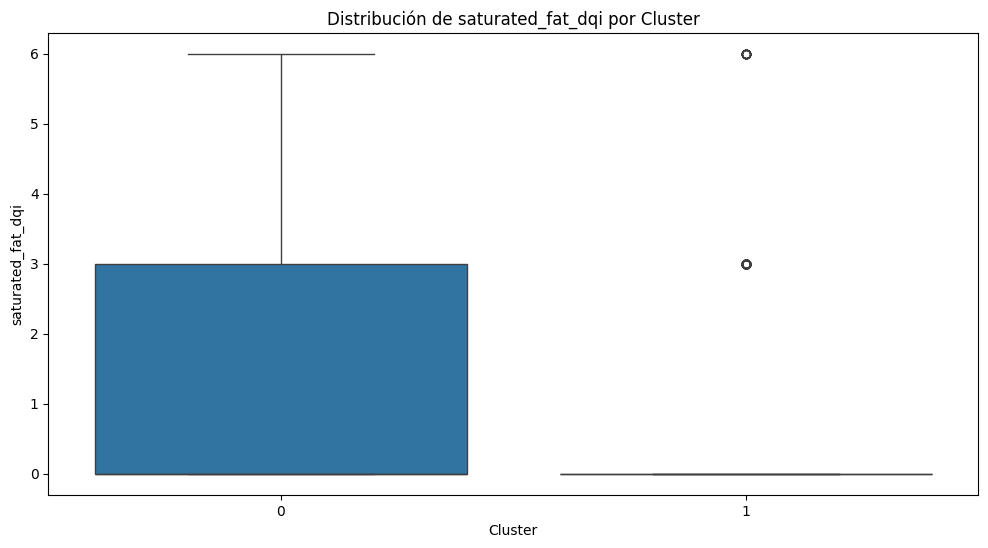

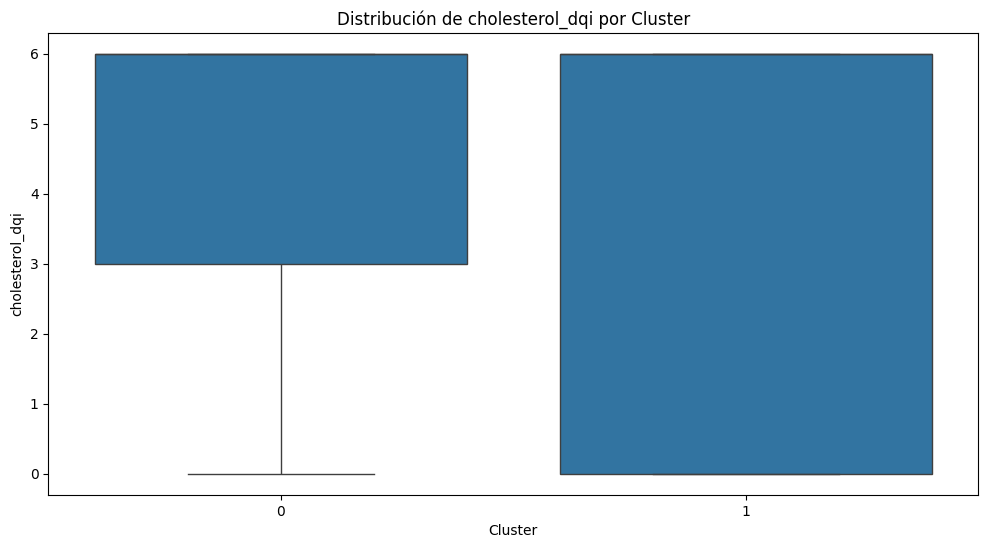

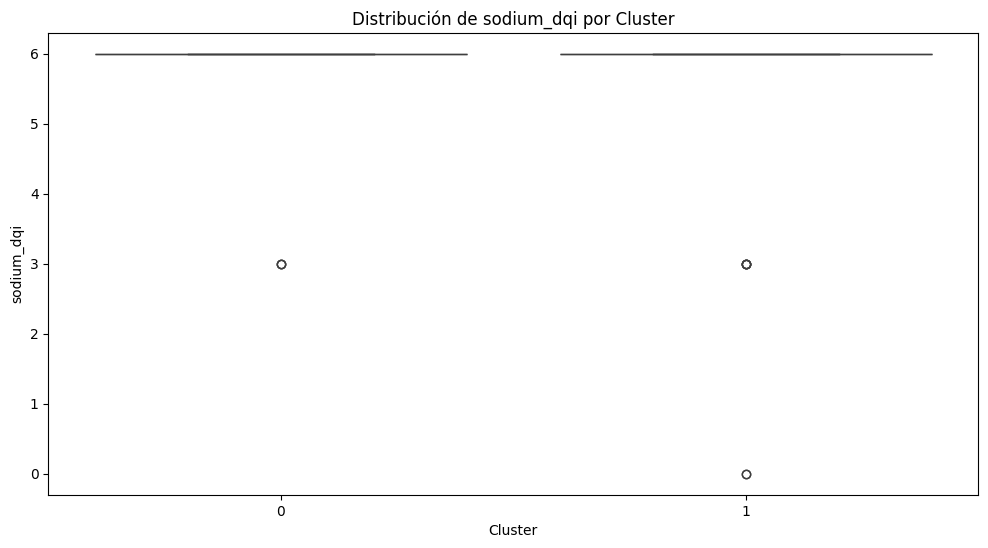

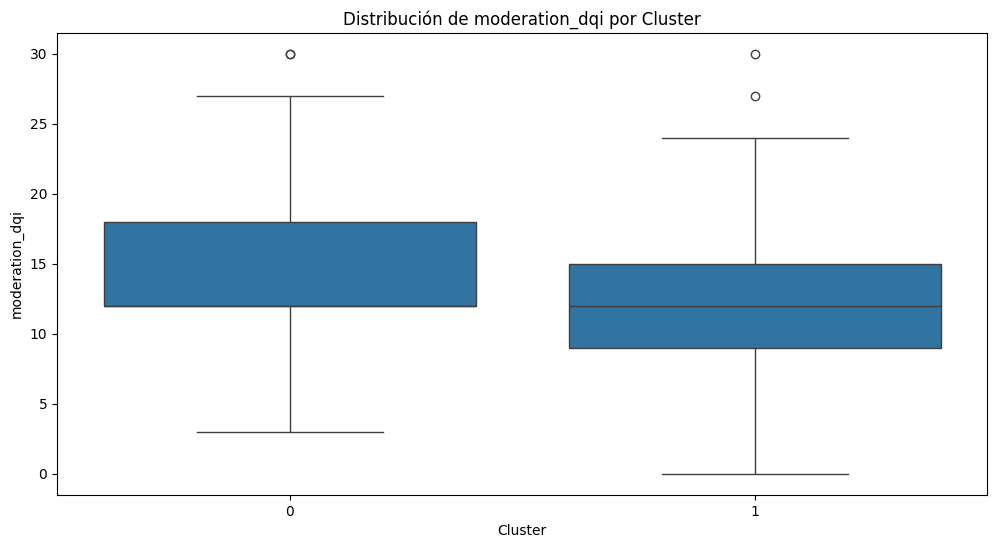

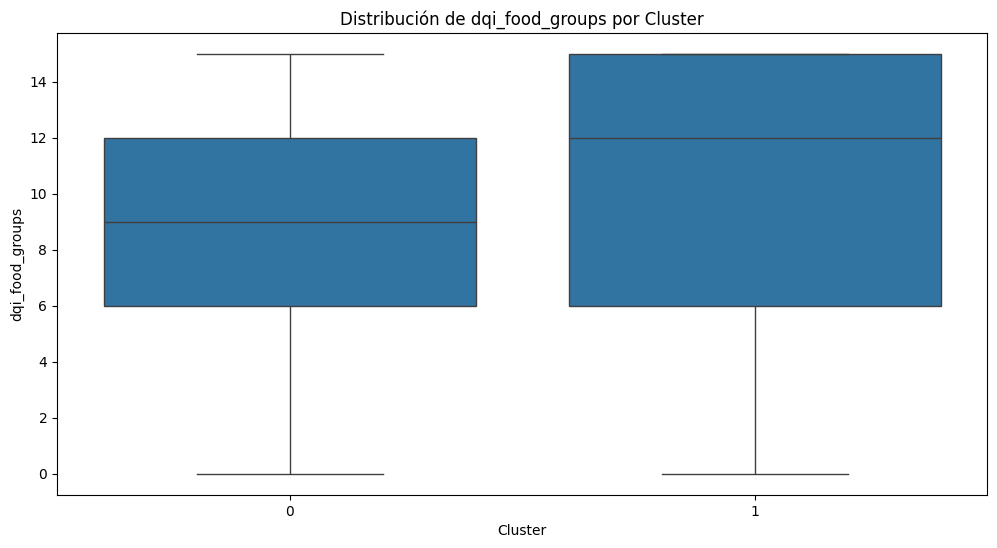

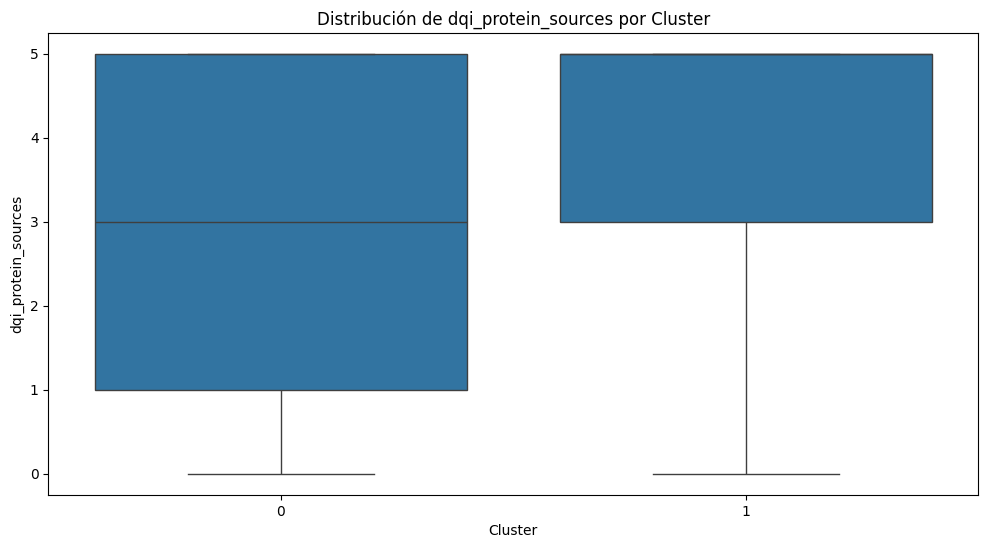

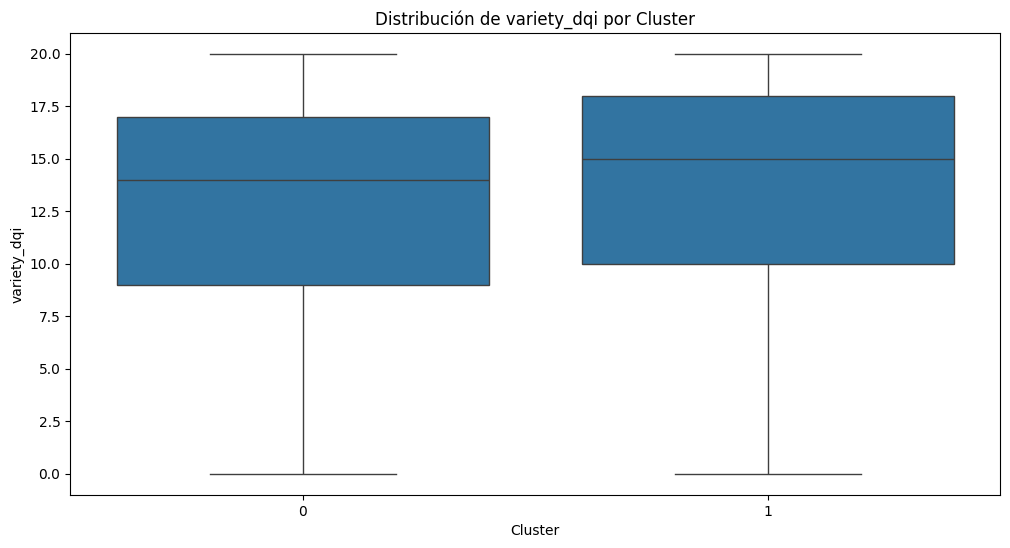

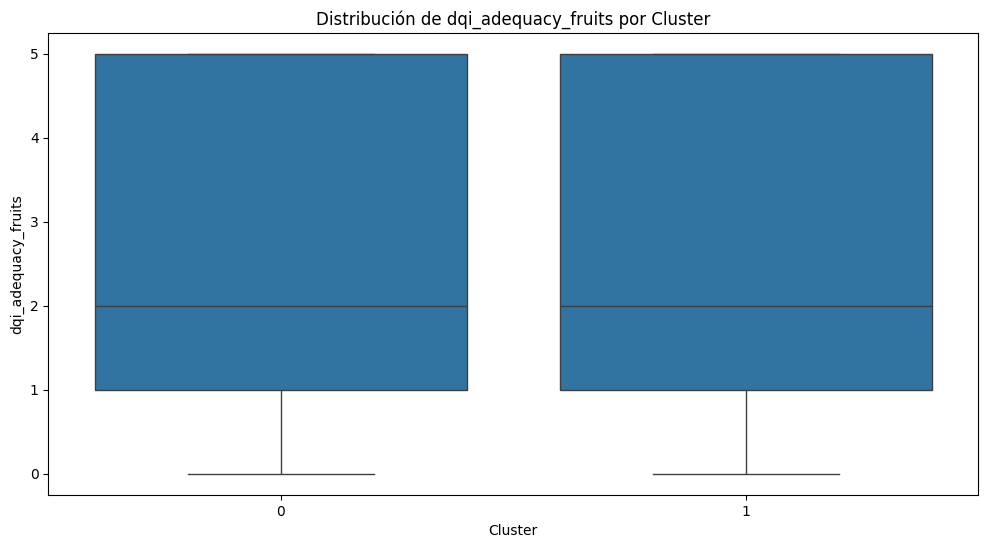

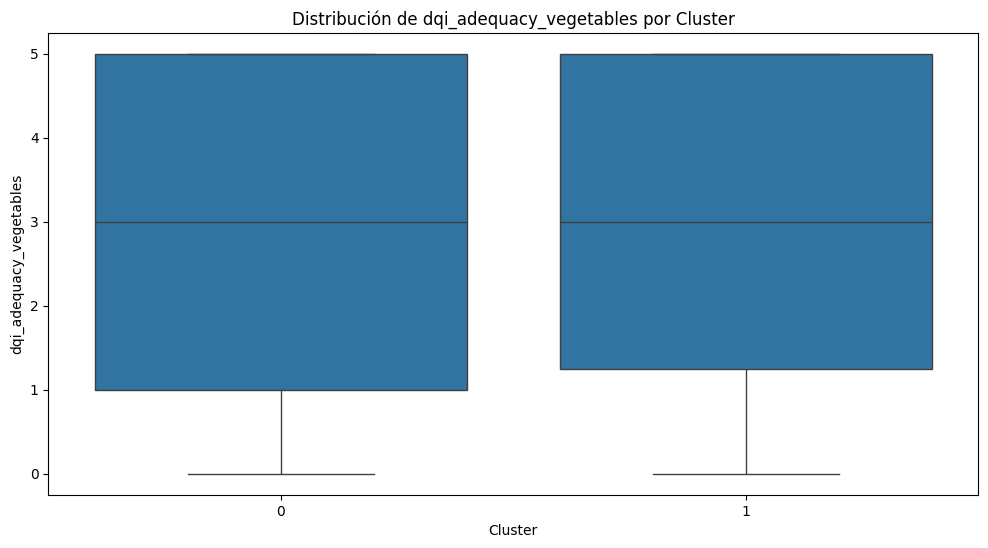

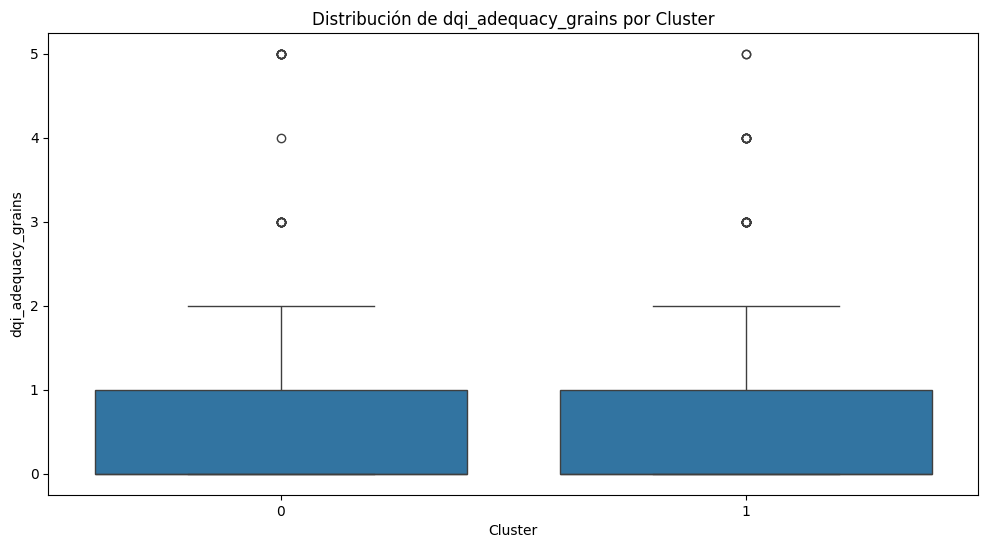

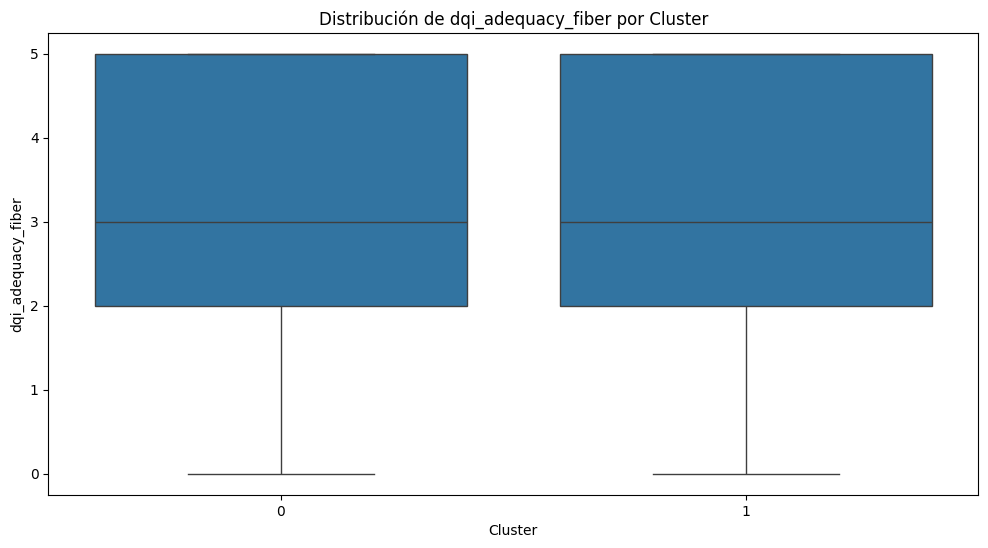

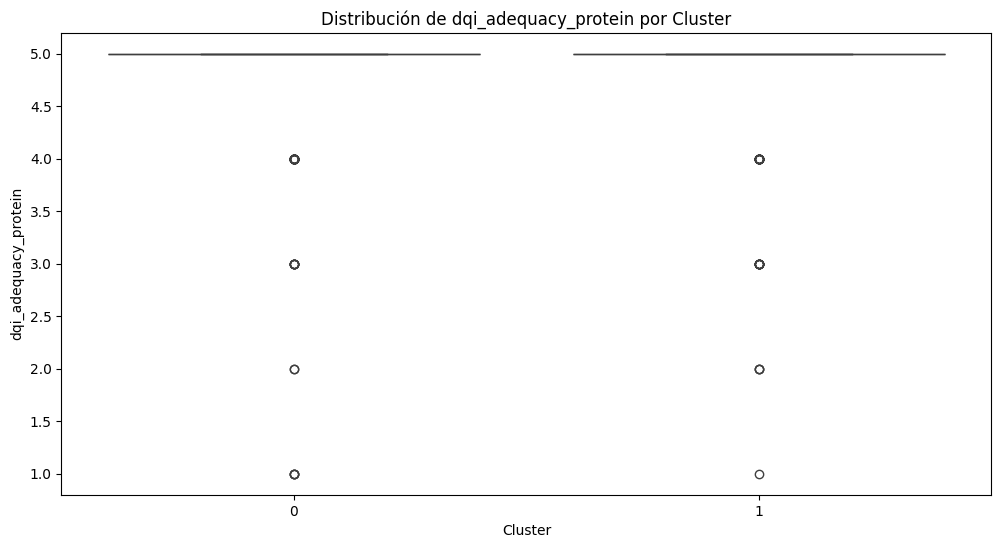

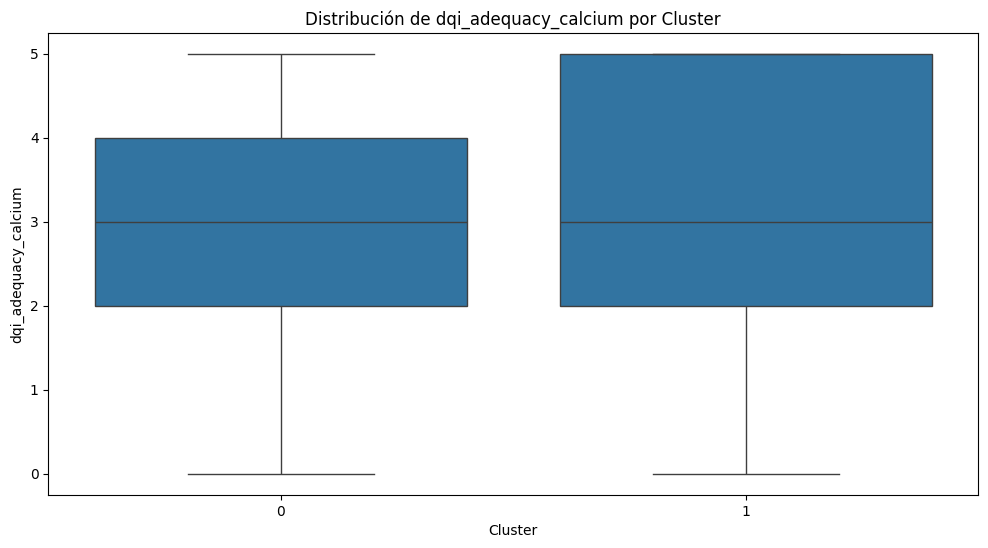

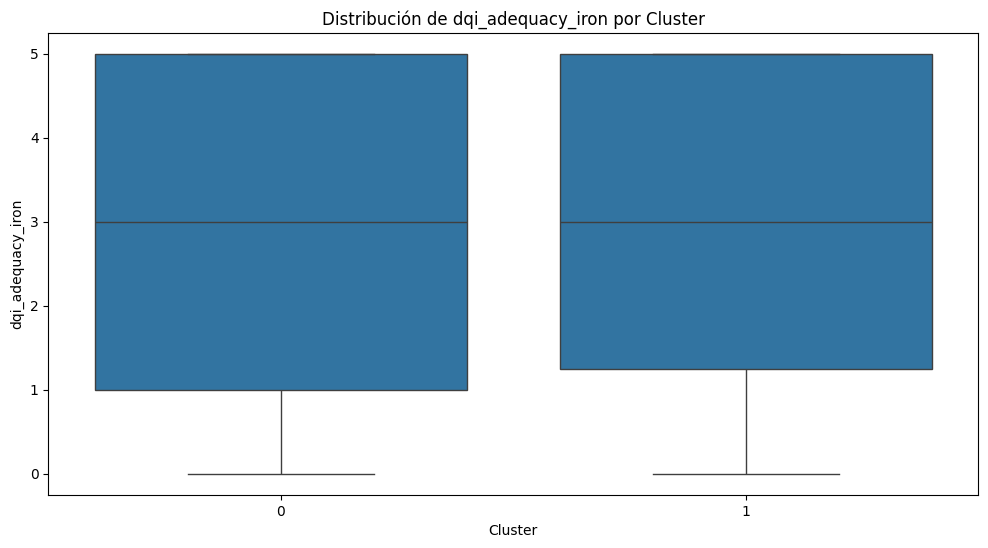

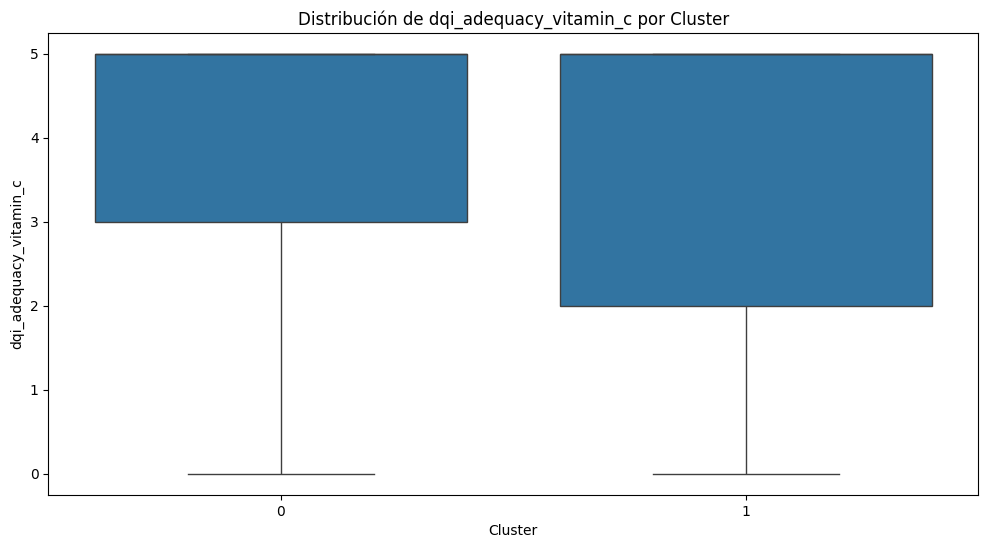

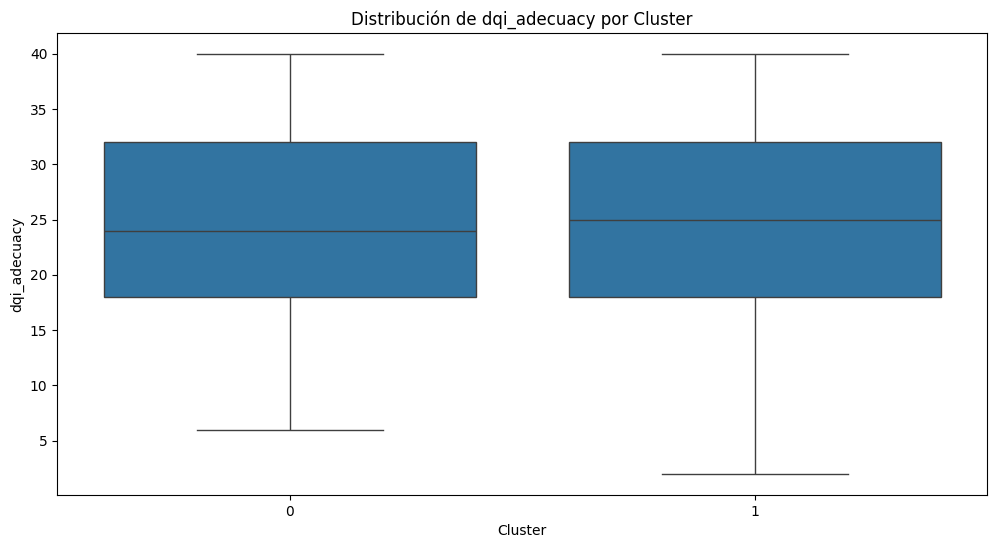

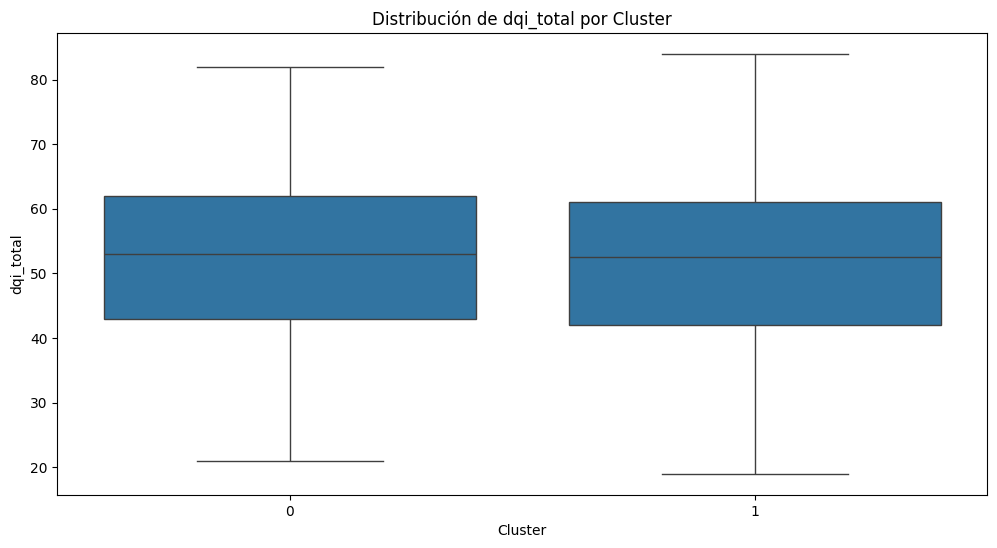

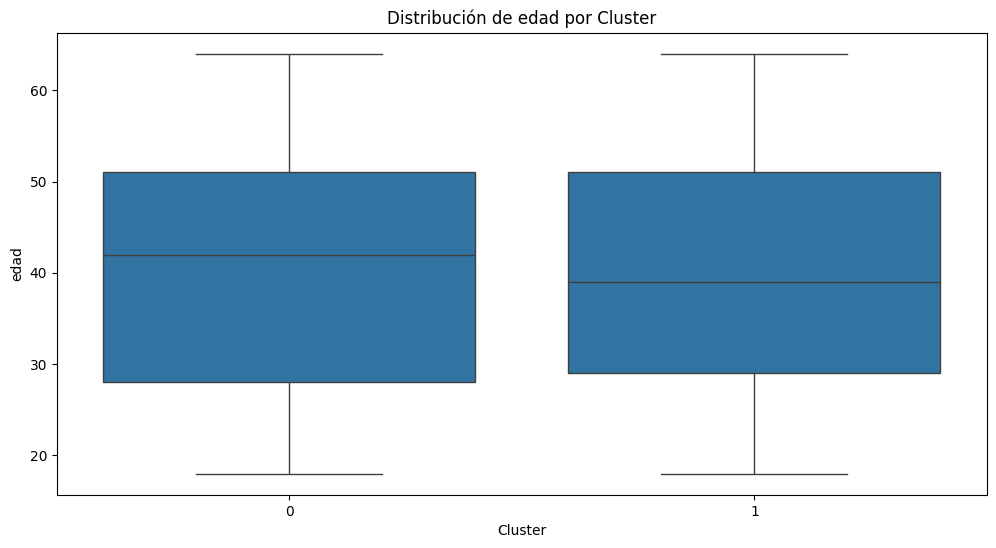

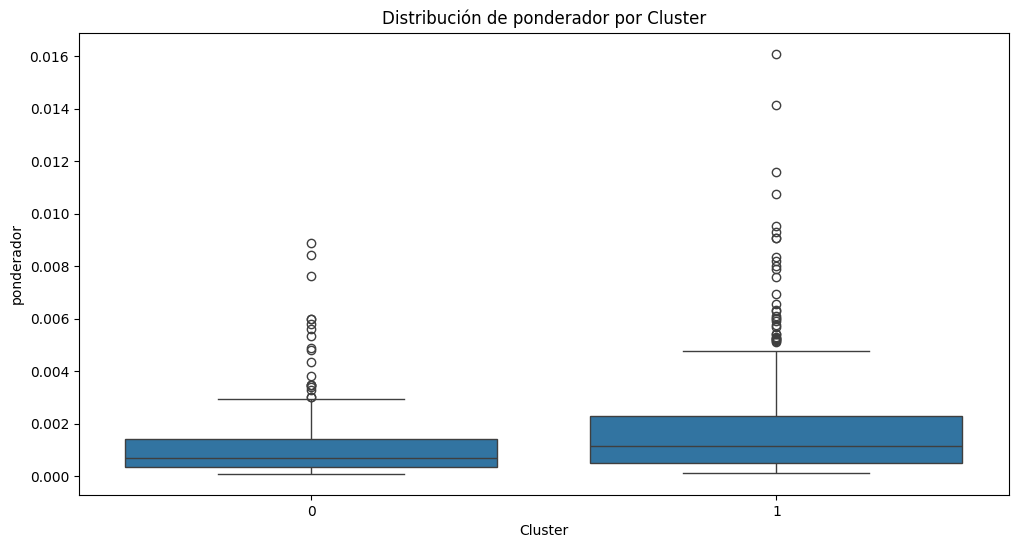

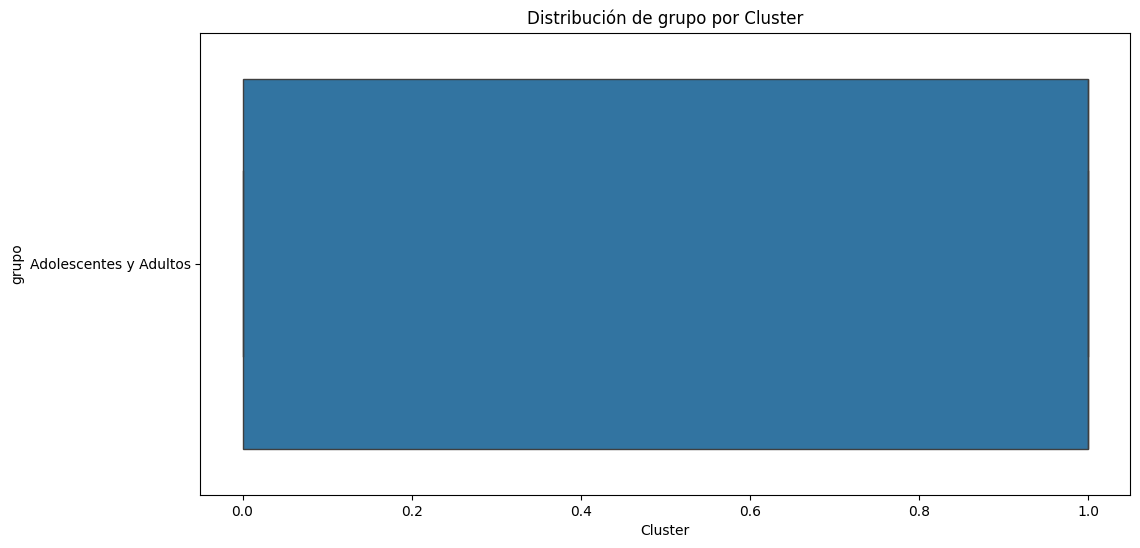

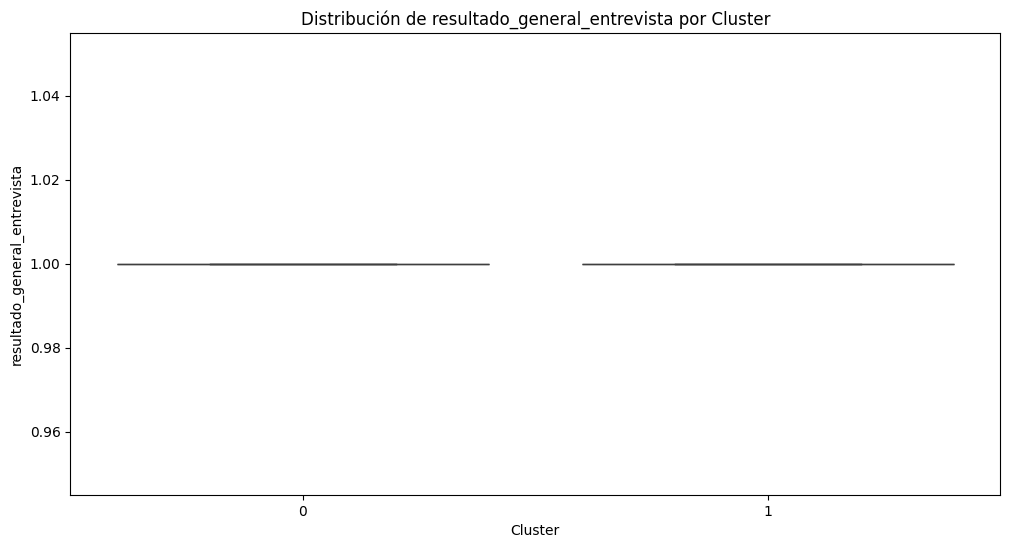

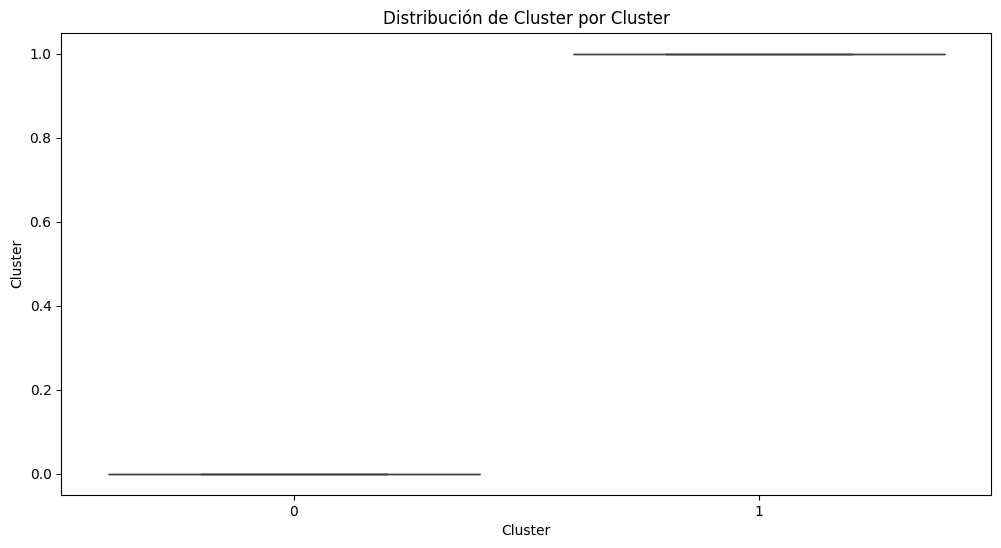

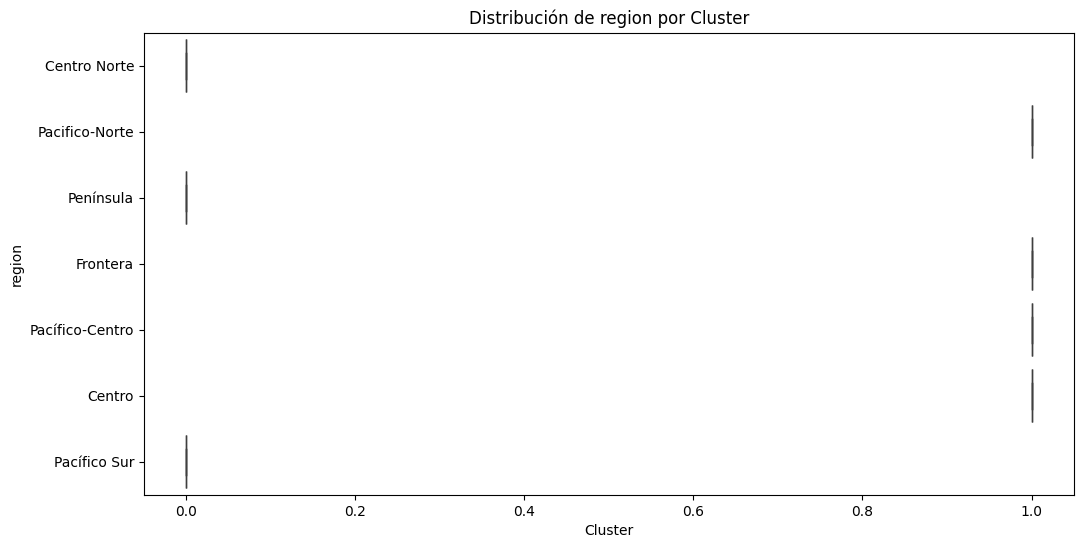

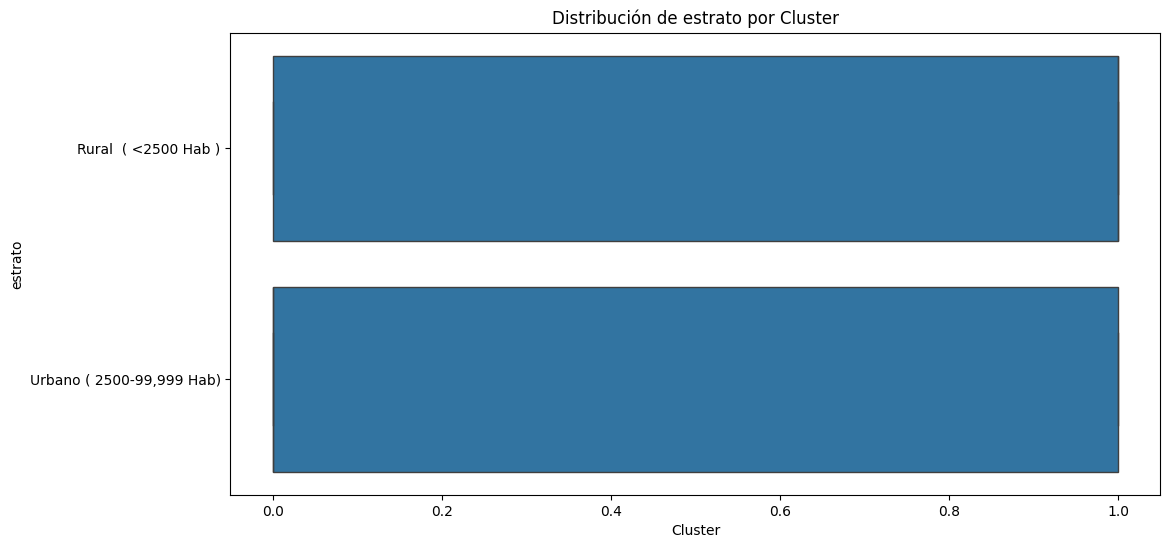

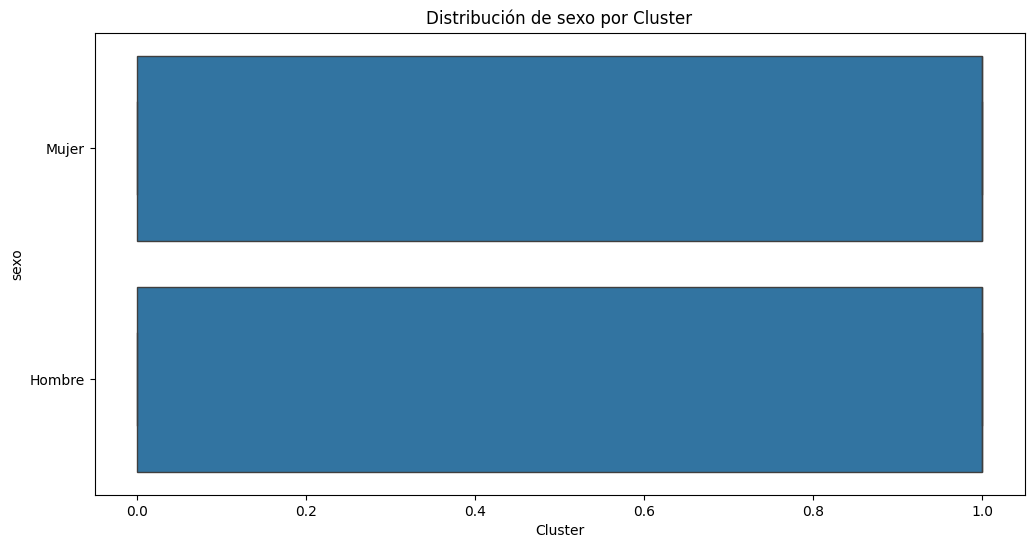

In [407]:
df_dqi = df_dqi.drop('folio_integrante', axis=1)
dqi_columns = df_dqi.columns
for column in dqi_columns:
    boxplot(df_dqi, 'Cluster', column, title=f'Distribución de {column} por Cluster')
    

### Conclusiones del modelo GMM

El data frame usado tiene muchas caracteristicas por lo que se uso PCA para disminuirlas. Como se observa en las graficas del puntaje de la silueta el modelo GMM no da resultados positivos. Es decir, la super posicion entre clusters es muy grande. Incluso en el spider plot se observa como con dos clusters (lo cual ofrece el mejor puntaje de 0.065) se puede observar como es una super posicion muy grande. Al mismo tiempo se puede observar como hay una clara diferenciacion en dos caracteristicas

Debido a los resultados que arroja el GMM no se recomendia como modelo a usarse para este problema.